In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import random
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv("group_30_multiple_imputed.csv")

seed =42
np.random.seed(seed)
random.seed(seed)

In [2]:
 # Split the data into train and test sets (stratified).
X = df.drop('diagnosis', axis=1)  
y = df['diagnosis'] 
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train set size:', X_train.shape)
print('Test set size:', X_test.shape)

Train set size: (1296, 15)
Test set size: (324, 15)


In [3]:
#Preprocess the data - Label encoding for target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [4]:
print("CLASS IMBALANCE ANALYSIS")
print("-"*40)
# compute the weighted average
unique_classes = np.unique(y_train_encoded)
class_weights = compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=y_train_encoded
)
class_weight_dict = dict(zip(unique_classes, class_weights))

print(f"Number of classes: {len(unique_classes)}")
print(f"Classes: {unique_classes}")
print(f"Class weights: {class_weight_dict}")

# display the category distribution
class_counts = pd.Series(y_train_encoded).value_counts().sort_index()
class_percentages = (class_counts / len(y_train_encoded) * 100).round(2)

print("\nClass distribution in training set:")
for cls, count, perc in zip(class_counts.index, class_counts.values, class_percentages.values):
    print(f"  Class {cls} ({le.classes_[cls]}): {count} samples ({perc}%)")

CLASS IMBALANCE ANALYSIS
----------------------------------------
Number of classes: 3
Classes: [0 1 2]
Class weights: {np.int64(0): np.float64(1.3333333333333333), np.int64(1): np.float64(0.9515418502202643), np.int64(2): np.float64(0.833976833976834)}

Class distribution in training set:
  Class 0 (Both): 324 samples (25.0%)
  Class 1 (Depression): 454 samples (35.03%)
  Class 2 (ME/CFS): 518 samples (39.97%)


In [5]:
# Preprocess the data - One-hot encoding for categorical features
categorical_features = ['gender', 'pem_present', 'work_status','social_activity_level','exercise_frequency','meditation_or_mindfulness']

# Create ColumnTransformer for one-hot encoding categorical features and passing through numerical features
ct = ColumnTransformer([
     ('ohe', OneHotEncoder(), categorical_features)
], remainder='passthrough')

# Fit on training data and transform both train and test sets
X_train_processed_np = ct.fit_transform(X_train)
X_test_processed_np = ct.transform(X_test)

# Build column names: one-hot encoded names + numerical names
ohe_names = ct.named_transformers_['ohe'].get_feature_names_out(categorical_features).tolist()
numerical_feature_names = [col for col in X_train.columns if col not in categorical_features]

feature_names = ohe_names + numerical_feature_names

# Convert back to DataFrames (preserve indices)
X_train_processed = pd.DataFrame(X_train_processed_np, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed_np, columns=feature_names, index=X_test.index)

# Quick check
print('X_train_processed shape:', X_train_processed.shape)
print('X_test_processed shape:', X_test_processed.shape)

X_train_processed shape: (1296, 28)
X_test_processed shape: (324, 28)


In [6]:
n_classes = len(np.unique(y_train_encoded))

In [7]:
print("SPLIT DATA CLASSES ANALYSIS")
print("-"*60)
print(f"Number of unique classes in target variable: {n_classes}")
print(f"\nClasses: {le.classes_}")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train_encoded).value_counts().sort_index())
print(f"\nClass distribution in test set:")
print(pd.Series(y_test_encoded).value_counts().sort_index())

SPLIT DATA CLASSES ANALYSIS
------------------------------------------------------------
Number of unique classes in target variable: 3

Classes: ['Both' 'Depression' 'ME/CFS']

Class distribution in training set:
0    324
1    454
2    518
Name: count, dtype: int64

Class distribution in test set:
0     81
1    113
2    130
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [9]:
print("MODEL BUILDING AND HYPERPARAMETER TUNING")
print("--"*40)

# prepare the base model to compare with the tuned model
base_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
}

print("Hyperparameter Tuning Process")
tuned_models = {}

scoring_strategy='f1_weighted'
CV_strategy=StratifiedKFold (n_splits=10, shuffle=True, random_state=seed)

# logistic regression
print("\nTuning Logistic Regression...\n")
lr_param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 2, 5],  
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000],
    'class_weight': ['balanced'],
    'penalty': ['l2'],
    'tol': [1e-4, 1e-3, 1e-2]  
}
lr_grid = GridSearchCV(
    base_models['Logistic Regression'],
    lr_param_grid,
    cv=CV_strategy,
    scoring=scoring_strategy,
    n_jobs=-1,
    verbose=1,
)
lr_grid.fit(X_train_scaled, y_train_encoded)
tuned_models['Logistic Regression'] = lr_grid.best_estimator_
print(f" Best params: {lr_grid.best_params_}")
print(f" Best F1_weight score: {lr_grid.best_score_:.4f}")
print("\nLogistic Regression model has been tuned.\n")

# decision tree
print("\nTuning Decision Tree...\n")
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}
dt_grid = RandomizedSearchCV(
    base_models['Decision Tree'],
    dt_param_grid,
    n_iter=30,
    cv=CV_strategy,
    scoring=scoring_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
dt_grid.fit(X_train_scaled, y_train_encoded)
tuned_models['Decision Tree'] = dt_grid.best_estimator_
print(f" Best params: {dt_grid.best_params_}")
print(f" Best F1_weight score: {dt_grid.best_score_:.4f}")
print("\nDecision Tree model has been tuned.")

# random forest
print("\nTuning Random Forest...\n")
rf_param_grid = {
    'n_estimators': [100, 150, 200],  
    'max_depth': [5, 8, 10, 12, 15],  
    'min_samples_split': [5, 10, 15],  
    'min_samples_leaf': [2, 4, 6],     
    'max_features': ['sqrt', 0.5, 0.7],  
    'bootstrap': [True],  
    'class_weight': ['balanced', 'balanced_subsample']  
}
rf_grid = RandomizedSearchCV(
    base_models['Random Forest'],
    rf_param_grid,
    n_iter=50,
    cv=CV_strategy,
    scoring='roc_auc_ovr_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=seed
)
rf_grid.fit(X_train_scaled, y_train_encoded)
tuned_models['Random Forest'] = rf_grid.best_estimator_
print(f" Best params: {rf_grid.best_params_}")
print(f" Best roc_auc_ovr_weighted score: {rf_grid.best_score_:.4f}")
print("\nRandom Forest model has been tuned.")


models = tuned_models
print("\n" + "-"*80)
print("MODEL TUNING COMPLETED")

MODEL BUILDING AND HYPERPARAMETER TUNING
--------------------------------------------------------------------------------
Hyperparameter Tuning Process

Tuning Logistic Regression...

Fitting 10 folds for each of 72 candidates, totalling 720 fits
 Best params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.001}
 Best F1_weight score: 0.7928

Logistic Regression model has been tuned.


Tuning Decision Tree...

Fitting 10 folds for each of 30 candidates, totalling 300 fits
 Best params: {'min_samples_split': 5, 'min_samples_leaf': 8, 'max_depth': 5, 'criterion': 'entropy'}
 Best F1_weight score: 0.8132

Decision Tree model has been tuned.

Tuning Random Forest...

Fitting 10 folds for each of 50 candidates, totalling 500 fits
 Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 8, 'class_weight': 'balanced_subsample', 'bootstrap': True}
 Best roc_auc_ovr_weighted score: 0

TUNING EFFECT COMPARISON
----------------------------------------


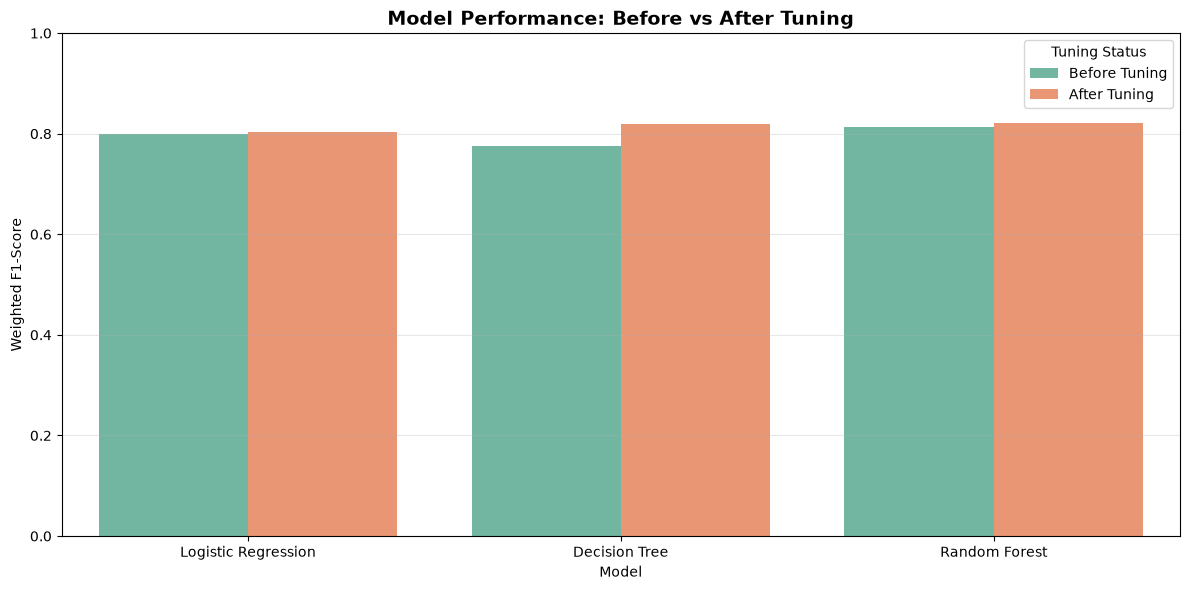

In [10]:
print("TUNING EFFECT COMPARISON")
print("-"*40)

base_performance = []
for name, base_model in base_models.items():
    base_model.fit(X_train_scaled, y_train_encoded)
    y_pred = base_model.predict(X_test_scaled)
    base_performance.append({
        'Model': name,
        'Type': 'Before Tuning',
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'F1 Weighted': f1_score(y_test_encoded, y_pred, average='weighted')
    })

tuned_performance = []
for name, tuned_model in tuned_models.items():
    y_pred = tuned_model.predict(X_test_scaled)
    tuned_performance.append({
        'Model': name,
        'Type': 'After Tuning',
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'F1 Weighted': f1_score(y_test_encoded, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(base_performance + tuned_performance)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Model', y='F1 Weighted', hue='Type', palette='Set2')
plt.title('Model Performance: Before vs After Tuning', fontsize=14, fontweight='bold')
plt.ylabel('Weighted F1-Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Tuning Status')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [11]:
results = {
    'model': [],
    'cv_mean_accuracy': [],
    'cv_std_accuracy': [],
    'test_accuracy': [],
    'test_precision_macro': [],
    'test_recall_macro': [],
    'test_f1_macro': [],
    'test_precision_weighted': [],
    'test_recall_weighted': [],
    'test_f1_weighted': [],
    'test_recall_minority': [], 
    'test_roc_auc_ovr': []
}

In [12]:
print("10-FOLD CROSS VALIDATION RESULTS (WITH CLASS WEIGHTS)")

cv_scores_all = {}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

# binarize the multi-class data for ROC and AUC computation
y_test_binarized = label_binarize(y_test_encoded, classes=range(n_classes))

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # cross-validation evaluation -use F1 score to focus on minority perforance
    cv_scores = cross_val_score(model, X_train_scaled, y_train_encoded, 
                                cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_scores_all[name] = cv_scores
    
    # fit training data on the model
    model.fit(X_train_scaled, y_train_encoded)
    
    # predict test data on the model
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
    
    # store the evaluation result
    results['model'].append(name)
    results['cv_mean_accuracy'].append(cv_scores.mean())
    results['cv_std_accuracy'].append(cv_scores.std())
    results['test_accuracy'].append(accuracy_score(y_test_encoded, y_pred))
    
    results['test_precision_macro'].append(precision_score(y_test_encoded, y_pred, average='macro'))
    results['test_recall_macro'].append(recall_score(y_test_encoded, y_pred, average='macro'))
    results['test_f1_macro'].append(f1_score(y_test_encoded, y_pred, average='macro'))
    results['test_precision_weighted'].append(precision_score(y_test_encoded, y_pred, average='weighted'))
    results['test_recall_weighted'].append(recall_score(y_test_encoded, y_pred, average='weighted'))
    results['test_f1_weighted'].append(f1_score(y_test_encoded, y_pred, average='weighted'))
    
    recall_by_class = recall_score(y_test_encoded, y_pred, average=None)
   
    # find the minimum recall rate (typically the minority category)
    results['test_recall_minority'].append(np.min(recall_by_class))
    
    # ROC AUC computation
    if y_pred_proba is not None:
        # one vs rest
        roc_auc_scores = []
        for i in range(n_classes):
            if len(np.unique(y_test_binarized[:, i])) > 1:
                roc_auc_scores.append(roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i]))
        results['test_roc_auc_ovr'].append(np.mean(roc_auc_scores) if roc_auc_scores else np.nan)
    else:
        results['test_roc_auc_ovr'].append(np.nan)
    print(f"\n{name} has been evaluated. ")

10-FOLD CROSS VALIDATION RESULTS (WITH CLASS WEIGHTS)

Evaluating Logistic Regression...

Logistic Regression has been evaluated. 

Evaluating Decision Tree...

Decision Tree has been evaluated. 

Evaluating Random Forest...

Random Forest has been evaluated. 


MODEL PERFORMANCE COMPARISON (WITH CLASS IMBALANCE HANDLING)
              model  cv_mean_accuracy  cv_std_accuracy  test_f1_weighted  test_recall_minority  test_roc_auc_ovr
Logistic Regression            0.7928           0.0405            0.8034                0.7538            0.9324
      Decision Tree            0.8132           0.0340            0.8198                0.7284            0.9419
      Random Forest            0.8225           0.0342            0.8214                0.6667            0.9493


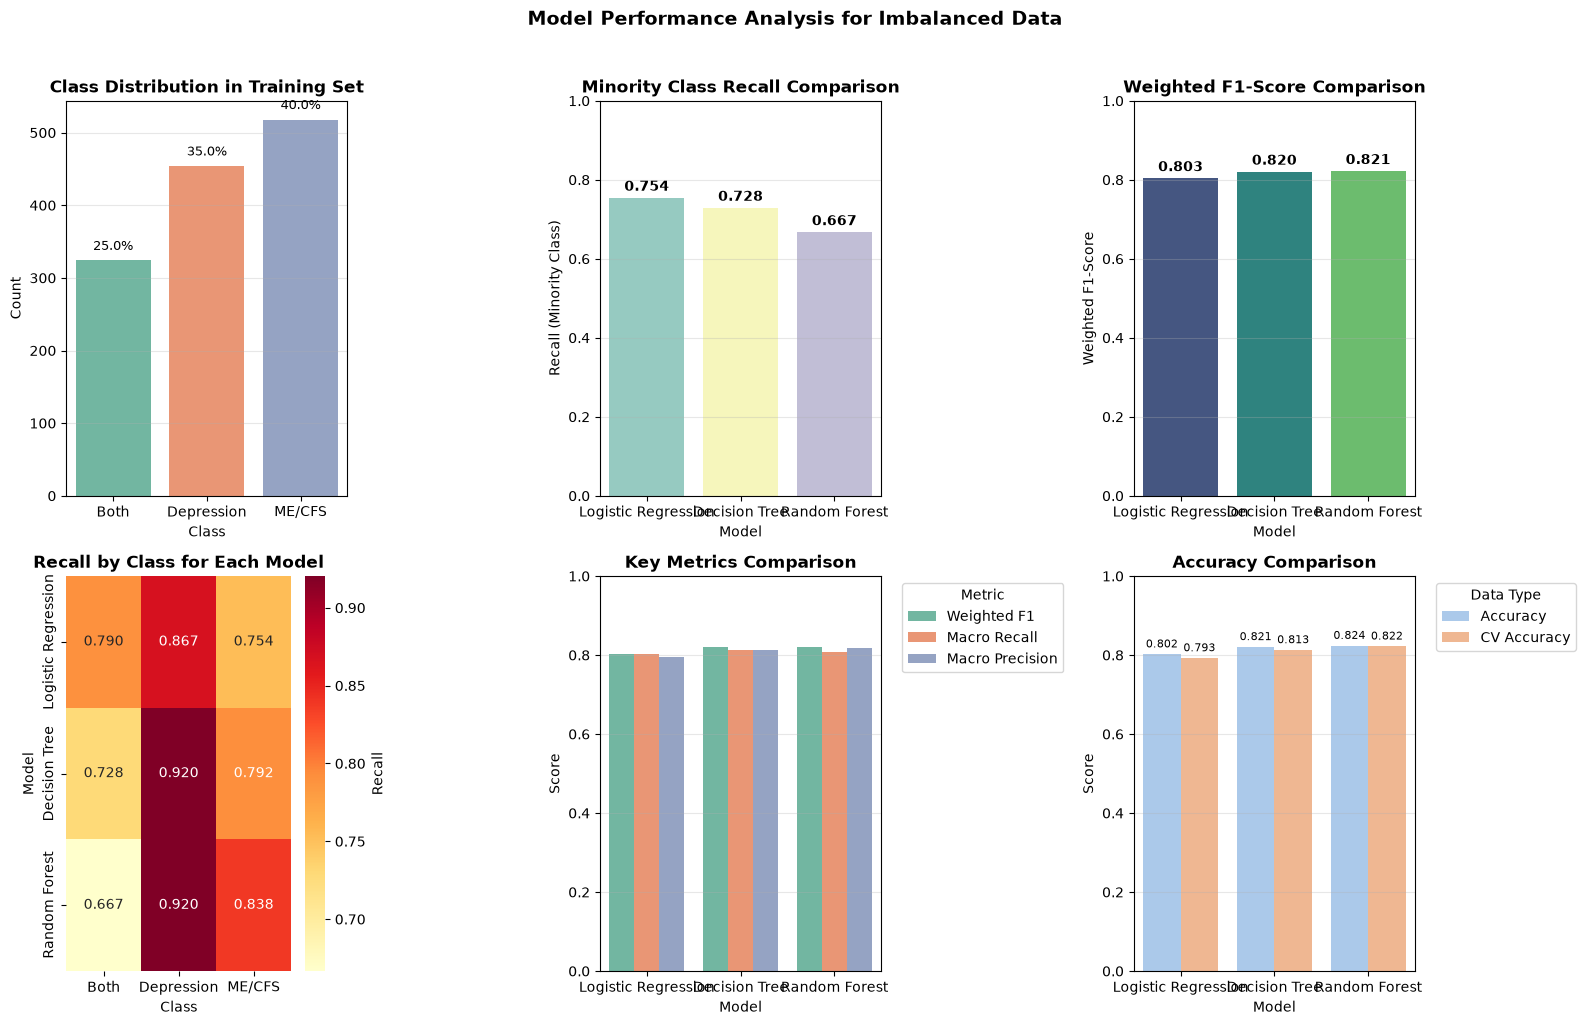


SIMPLIFIED PERFORMANCE COMPARISON


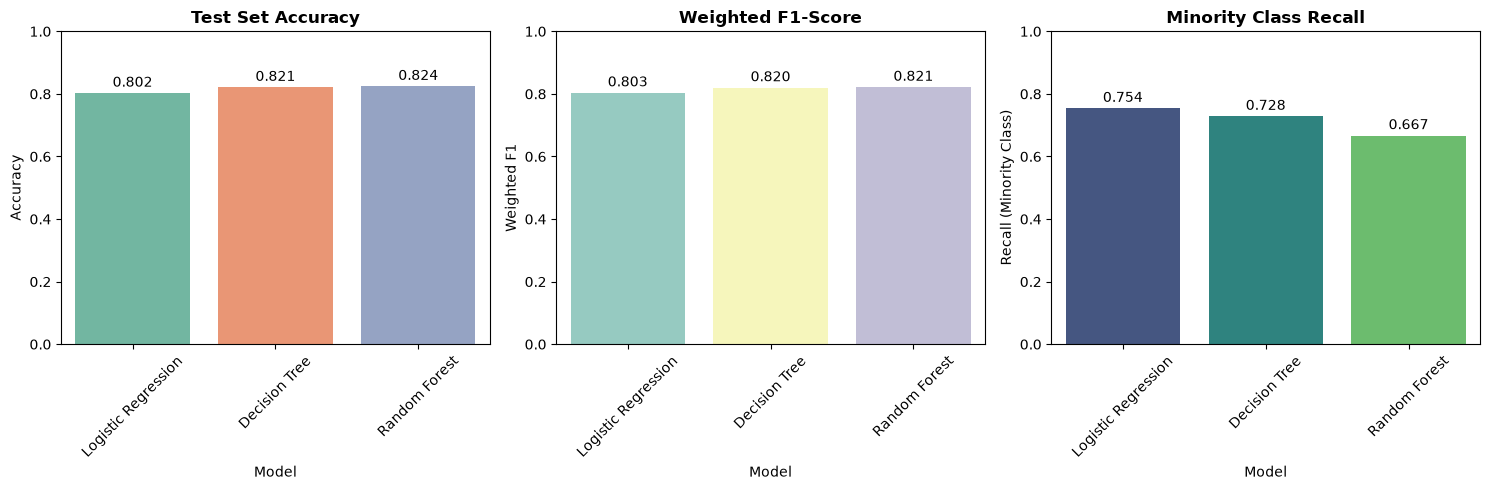

In [13]:
results_df = pd.DataFrame(results)
print("MODEL PERFORMANCE COMPARISON (WITH CLASS IMBALANCE HANDLING)")

display_columns = ['model', 'cv_mean_accuracy', 'cv_std_accuracy', 
                   'test_f1_weighted', 'test_recall_minority', 'test_roc_auc_ovr']
print(results_df[display_columns].to_string(index=False, float_format='{:.4f}'.format))

import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

model_names = list(models.keys())
n_models = len(model_names)

# to ensure the dateframe have the same array amount with model
if len(results_df) != n_models:
    temp_results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train_encoded)
        y_pred = model.predict(X_test_scaled)
        
        accuracy = accuracy_score(y_test_encoded, y_pred)
        f1_weighted = f1_score(y_test_encoded, y_pred, average='weighted')
        recall_by_class = recall_score(y_test_encoded, y_pred, average=None)
        minority_recall = np.min(recall_by_class) if recall_by_class.size > 0 else 0
        
        temp_results.append({
            'model': name,
            'test_accuracy': accuracy,
            'test_f1_weighted': f1_weighted,
            'test_recall_minority': minority_recall
        })
    # use the temporary result
    temp_results_df = pd.DataFrame(temp_results)
    results_df_to_use = temp_results_df
else:
    results_df_to_use = results_df

# figure 1：category distribution
ax1 = axes[0, 0]
class_df = pd.DataFrame({
    'Class': le.classes_[:n_classes],  
    'Count': class_counts.values[:n_classes],
    'Percentage': class_percentages.values[:n_classes]
})
bars = sns.barplot(data=class_df, x='Class', y='Count', ax=ax1, palette='Set2')
ax1.set_title('Class Distribution in Training Set', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3, axis='y')

for i, (bar, perc) in enumerate(zip(bars.patches, class_percentages.values[:n_classes])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + max(class_counts.values[:n_classes])*0.02, 
             f'{perc:.1f}%', ha='center', va='bottom', fontsize=9)

# figure 2: recall rate for minority category comparison
ax2 = axes[0, 1]
minority_recall_values = results_df_to_use['test_recall_minority'].values[:n_models]

minority_df = pd.DataFrame({
    'Model': model_names,
    'Minority Recall': minority_recall_values
})
bars = sns.barplot(data=minority_df, x='Model', y='Minority Recall', ax=ax2, palette='Set3')
ax2.set_title('Minority Class Recall Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('Model')
ax2.set_ylabel('Recall (Minority Class)')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars.patches:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# figure 3：F1 comparision
ax3 = axes[0, 2]
f1_values = results_df_to_use['test_f1_weighted'].values[:n_models]

f1_df = pd.DataFrame({
    'Model': model_names,
    'Weighted F1': f1_values
})
bars = sns.barplot(data=f1_df, x='Model', y='Weighted F1', ax=ax3, palette='viridis')
ax3.set_title('Weighted F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xlabel('Model')
ax3.set_ylabel('Weighted F1-Score')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3, axis='y')

for bar in bars.patches:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# figure4：recall rate for heatmap for each category
ax4 = axes[1, 0]

recall_matrix = []

for name in model_names:
    model = models[name]
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    recall_by_class = recall_score(y_test_encoded, y_pred, average=None)
    

    if len(recall_by_class) != n_classes:
        recall_by_class = np.zeros(n_classes)
    recall_matrix.append(recall_by_class)

recall_matrix = np.array(recall_matrix)
recall_df = pd.DataFrame(recall_matrix, 
                         index=model_names, 
                         columns=[f'{le.classes_[i]}' for i in range(n_classes)])

sns.heatmap(recall_df, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Recall'}, ax=ax4)
ax4.set_title('Recall by Class for Each Model', fontsize=12, fontweight='bold')
ax4.set_xlabel('Class')
ax4.set_ylabel('Model')

# figure 5：performance comparison of each model
ax5 = axes[1, 1]
comparison_data = []
metrics_to_show = {
    'Weighted F1': 'test_f1_weighted',
    'Macro Recall': 'test_recall_macro',
    'Macro Precision': 'test_precision_macro'
}
for model_name in model_names:
    if model_name in results_df_to_use['model'].values:
        model_results = results_df_to_use[results_df_to_use['model'] == model_name].iloc[0]
    else:
        model_results = {
            'test_f1_weighted': 0,
            'test_recall_macro': 0,
            'test_precision_macro': 0
        }
    
    for display_name, metric_col in metrics_to_show.items():
        if metric_col in model_results:
            score = model_results[metric_col]
        else:
            score = 0  # 默认值
        
        comparison_data.append({
            'Model': model_name,
            'Metric': display_name,
            'Score': score
        })

comparison_df = pd.DataFrame(comparison_data)

sns.barplot(data=comparison_df, x='Model', y='Score', hue='Metric', 
            ax=ax5, palette='Set2')
ax5.set_title('Key Metrics Comparison', fontsize=12, fontweight='bold')
ax5.set_xlabel('Model')
ax5.set_ylabel('Score')
ax5.set_ylim(0, 1)
ax5.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax5.grid(True, alpha=0.3, axis='y')

# figure 6：accuracy comparison
ax6 = axes[1, 2]
accuracy_values = results_df_to_use['test_accuracy'].values[:n_models]

if 'cv_mean_accuracy' in results_df_to_use.columns:
    cv_values = results_df_to_use['cv_mean_accuracy'].values[:n_models]
else:
    cv_values = [0] * n_models  

accuracy_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_values,
    'CV Accuracy': cv_values
})

accuracy_melted = accuracy_df.melt(id_vars=['Model'], 
                                   value_vars=['Accuracy', 'CV Accuracy'],
                                   var_name='Type', value_name='Score')

sns.barplot(data=accuracy_melted, x='Model', y='Score', hue='Type', 
            ax=ax6, palette='pastel')
ax6.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax6.set_xlabel('Model')
ax6.set_ylabel('Score')
ax6.set_ylim(0, 1)
ax6.legend(title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True, alpha=0.3, axis='y')

for i, model_name in enumerate(model_names):
    test_acc = accuracy_values[i]
    cv_acc = cv_values[i] 
    ax6.text(i - 0.2, test_acc + 0.01, f'{test_acc:.3f}', 
             ha='center', va='bottom', fontsize=8)
    ax6.text(i + 0.2, cv_acc + 0.01, f'{cv_acc:.3f}', 
             ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Analysis for Imbalanced Data', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SIMPLIFIED PERFORMANCE COMPARISON")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# figure 1：accuracy comparison
acc_ax = axes[0]
acc_data = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_values
})
sns.barplot(data=acc_data, x='Model', y='Accuracy', ax=acc_ax, palette='Set2')
acc_ax.set_title('Test Set Accuracy', fontsize=12, fontweight='bold')
acc_ax.set_ylabel('Accuracy')
acc_ax.set_ylim(0, 1)
acc_ax.tick_params(axis='x', rotation=45)

for i, bar in enumerate(acc_ax.patches):
    height = bar.get_height()
    acc_ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.3f}', ha='center', va='bottom')

# figure 2：weighted F1 score comparison
f1_ax = axes[1]
f1_data = pd.DataFrame({
    'Model': model_names,
    'Weighted F1': f1_values
})
sns.barplot(data=f1_data, x='Model', y='Weighted F1', ax=f1_ax, palette='Set3')
f1_ax.set_title('Weighted F1-Score', fontsize=12, fontweight='bold')
f1_ax.set_ylabel('Weighted F1')
f1_ax.set_ylim(0, 1)
f1_ax.tick_params(axis='x', rotation=45)

for i, bar in enumerate(f1_ax.patches):
    height = bar.get_height()
    f1_ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
               f'{height:.3f}', ha='center', va='bottom')

# figure 3：minority recall rate comparison
minority_ax = axes[2]
minority_data = pd.DataFrame({
    'Model': model_names,
    'Minority Recall': minority_recall_values
})
sns.barplot(data=minority_data, x='Model', y='Minority Recall', 
            ax=minority_ax, palette='viridis')
minority_ax.set_title('Minority Class Recall', fontsize=12, fontweight='bold')
minority_ax.set_ylabel('Recall (Minority Class)')
minority_ax.set_ylim(0, 1)
minority_ax.tick_params(axis='x', rotation=45)

for i, bar in enumerate(minority_ax.patches):
    height = bar.get_height()
    minority_ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                     f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

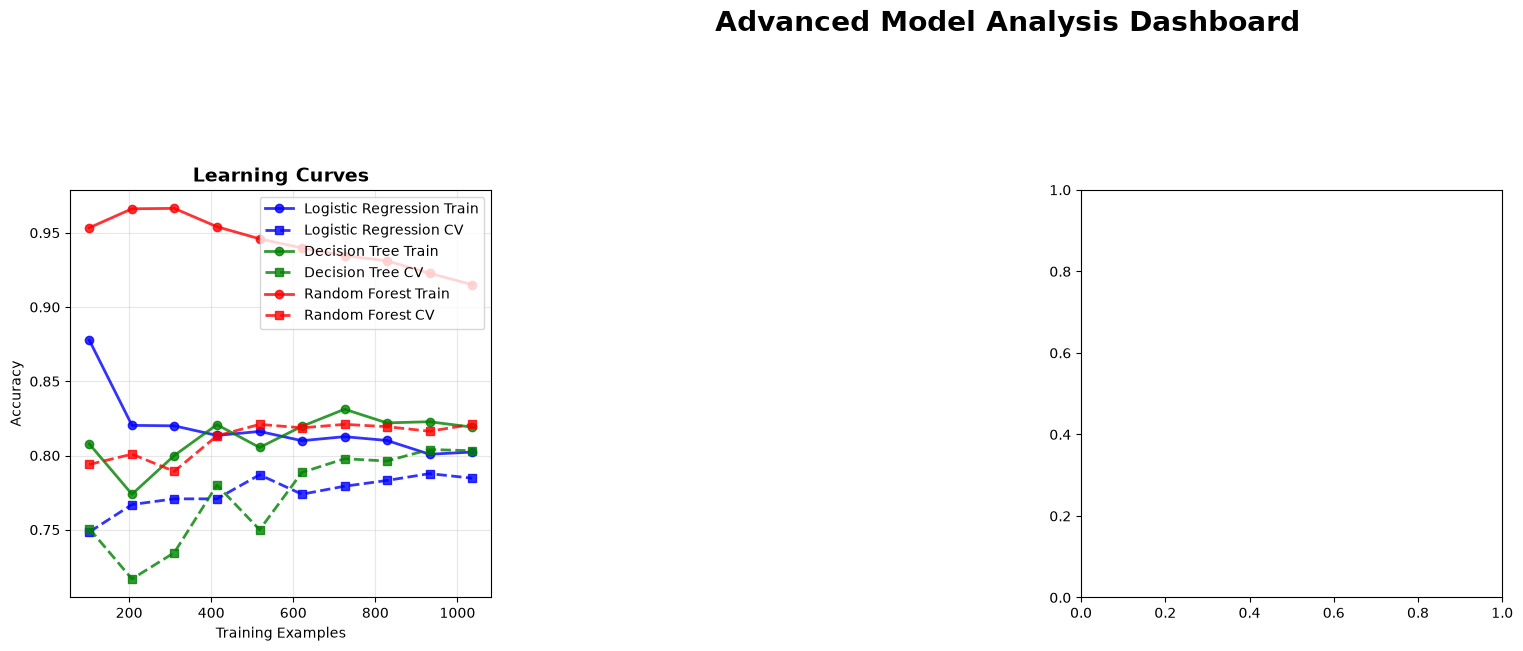

In [14]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

fig = plt.figure(figsize=(25, 18))  
fig.suptitle('Advanced Model Analysis Dashboard', fontsize=20, fontweight='bold', y=0.98)

def extract_feature_importance(models_dict, feature_names):
    #Extract feature importance from different models
    importance_dict = {}
    for name, model in models_dict.items():
        model.fit(X_train_scaled, y_train_encoded)
        if hasattr(model, 'feature_importances_'):
            importance_dict[name] = model.feature_importances_
        elif hasattr(model, 'coef_'):
            importance_dict[name] = np.abs(model.coef_).mean(axis=0)  
    return importance_dict

def plot_learning_curve(ax):
    #Plot learning curves for all models
    train_sizes = np.linspace(0.1, 1.0, 10)
    colors = ['blue', 'green', 'red']
    
    for (name, model), color in zip(models.items(), colors):
        train_sizes_abs, train_scores, test_scores = learning_curve(
            model, X_train_scaled, y_train_encoded,
            train_sizes=train_sizes, cv=5, n_jobs=-1, scoring='accuracy'
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        ax.plot(train_sizes_abs, train_mean, 'o-', color=color, 
                label=f'{name} Train', linewidth=2, alpha=0.8)
        ax.plot(train_sizes_abs, test_mean, 's--', color=color,
                label=f'{name} CV', linewidth=2, alpha=0.8)
        
    ax.set_title('Learning Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

def plot_model_stability(ax):
    #Plot model stability using 10-fold CV boxplot
    box_data = []
    for name in model_names:
        cv_scores = cross_val_score(models[name], X_train_scaled, y_train_encoded, 
                                   cv=10, scoring='accuracy', n_jobs=-1)
        box_data.append(cv_scores)
    
    bp = ax.boxplot(box_data, labels=model_names, patch_artist=True)
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title('Model Stability (10-fold CV)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3, axis='y')

#  Learning Curve 
ax1 = plt.subplot(3, 4, 1)
plot_learning_curve(ax1)

#  Model Stability 
ax2 = plt.subplot(3, 4, 3)   
plot_model_stability(ax2)   

# Model Performance Heatmap 
ax3 = plt.subplot(3, 4, 4)
metrics_config = {
    'test_accuracy': 'Accuracy',
    'test_precision_macro': 'Precision\n(macro)',
    'test_recall_macro': 'Recall\n(macro)',
    'test_f1_macro': 'F1-Score\n(macro)',
    'test_f1_weighted': 'F1-Score\n(weighted)',
    'test_roc_auc_ovr': 'ROC-AUC'
}

available_metrics = [m for m in metrics_config.keys() if m in results_df.columns]
if available_metrics:
    heatmap_data = results_df.set_index('model')[available_metrics]
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
               xticklabels=[metrics_config[m] for m in available_metrics], 
               yticklabels=model_names,
               cbar_kws={'label': 'Score'}, ax=ax3)
    ax3.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Metrics')
    ax3.set_ylabel('Model')
else:
    ax3.text(0.5, 0.5, 'No metric data available', 
             ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold')
    ax3.set_xticks([])
    ax3.set_yticks([])

#  Random Forest Top 10 Features
ax4 = plt.subplot(3, 4, 6)
feature_importance_dict = extract_feature_importance(models, feature_names)

if 'Random Forest' in feature_importance_dict:
    rf_importance = feature_importance_dict['Random Forest']
    top_indices = np.argsort(rf_importance)[-10:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_importance = rf_importance[top_indices]
    
    y_pos = np.arange(len(top_features))
    bars = ax4.barh(y_pos, top_importance, color='skyblue', alpha=0.8)  
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(top_features, fontsize=9)
    ax4.set_xlabel('Importance')
    ax4.set_title('Random Forest: Top 10 Features', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    for bar, imp in zip(bars, top_importance):
        width = bar.get_width()
        ax4.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{imp:.3f}', va='center', fontsize=8)
else:
    ax4.text(0.5, 0.5, 'Random Forest\nnot available', 
             ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('Random Forest: Top 10 Features', fontsize=14, fontweight='bold')
    ax4.set_xticks([])
    ax4.set_yticks([])

#  Plot 5: Top 10 Features (Average) 
ax5 = plt.subplot(3, 4, 7)
if feature_importance_dict and len(feature_importance_dict) > 0:
    importance_df = pd.DataFrame(feature_importance_dict, index=feature_names)
    avg_importance = importance_df.mean(axis=1).sort_values(ascending=False)[:10]
    
    y_pos = np.arange(len(avg_importance))
    bars = ax5.barh(y_pos, avg_importance.values,  
                   color='lightgreen', alpha=0.8)
    ax5.set_yticks(y_pos)
    ax5.set_yticklabels(avg_importance.index, fontsize=9)
    ax5.set_xlabel('Average Importance')
    ax5.set_title('Top 10 Features (Average)', fontsize=14, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='x')
    
    for bar, imp in zip(bars, avg_importance.values):
        width = bar.get_width()
        ax5.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{imp:.3f}', va='center', fontsize=8)
else:
    ax5.text(0.5, 0.5, 'No feature importance\ndata available', 
             ha='center', va='center', fontsize=12, transform=ax5.transAxes)
    ax5.set_title('Top 10 Features (Average)', fontsize=14, fontweight='bold')
    ax5.set_xticks([])
    ax5.set_yticks([])

#  Precision & Recall by Class 
ax6 = plt.subplot(3, 4, 8)
performance_data = []

for name in model_names:
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    precision, recall, _, _ = precision_recall_fscore_support(
        y_test_encoded, y_pred, average=None
    )
    
    for i, (p, r) in enumerate(zip(precision, recall)):
        performance_data.extend([
            {'Model': name, 'Class': le.classes_[i], 'Metric': 'Precision', 'Score': p},
            {'Model': name, 'Class': le.classes_[i], 'Metric': 'Recall', 'Score': r}
        ])

if performance_data:
    perf_df = pd.DataFrame(performance_data)
    pivot_df = perf_df.pivot_table(index=['Model', 'Class'], columns='Metric', 
                                  values='Score').reset_index()
    
    x = np.arange(len(model_names))
    width = 0.25  # Reduced width for better spacing
    
    for i, cls in enumerate(le.classes_):
        offset = width * i
        model_precisions = []
        model_recalls = []
        
        for name in model_names:
            subset = pivot_df[(pivot_df['Model'] == name) & (pivot_df['Class'] == cls)]
            model_precisions.append(subset['Precision'].values[0] if not subset.empty else 0)
            model_recalls.append(subset['Recall'].values[0] if not subset.empty else 0)
        
        if i == 0:
            ax6.bar(x + offset, model_precisions, width, label=f'{cls} Precision', alpha=0.7)
            ax6.bar(x + offset + width, model_recalls, width, label=f'{cls} Recall', alpha=0.7)
        else:
            ax6.bar(x + offset, model_precisions, width, alpha=0.7)
            ax6.bar(x + offset + width, model_recalls, width, alpha=0.7)
    
    ax6.set_xlabel('Model')
    ax6.set_ylabel('Score')
    ax6.set_title('Precision & Recall by Class', fontsize=14, fontweight='bold')
    ax6.set_xticks(x + width * (len(le.classes_) - 1) / 2)
    ax6.set_xticklabels(model_names)
    ax6.legend(title='Class & Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax6.set_ylim(0, 1)
    ax6.grid(True, alpha=0.3, axis='y')
else:
    ax6.text(0.5, 0.5, 'No performance data', 
             ha='center', va='center', fontsize=12, transform=ax6.transAxes)
    ax6.set_title('Precision & Recall by Class', fontsize=14, fontweight='bold')
    ax6.set_xticks([])
    ax6.set_yticks([])

# Class-wise Accuracy Heatmap 
ax7 = plt.subplot(3, 4, 10)
class_accuracy_data = []

for name in model_names:
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test_encoded, y_pred)
    accuracy_by_class = np.diag(cm) / cm.sum(axis=1)
    class_accuracy_data.append(accuracy_by_class)

if class_accuracy_data and len(class_accuracy_data) > 0:
    class_acc_df = pd.DataFrame(class_accuracy_data, index=model_names,
                               columns=[f'Class {i}' for i in range(n_classes)])
    
    sns.heatmap(class_acc_df, annot=True, fmt='.3f', cmap='RdYlGn', 
               cbar_kws={'label': 'Accuracy'}, ax=ax7)  # Fixed: ax7, not ax10
    ax7.set_title('Class-wise Accuracy', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Class')
    ax7.set_ylabel('Model')
else:
    ax7.text(0.5, 0.5, 'No confusion matrix data', 
             ha='center', va='center', fontsize=12, transform=ax7.transAxes)
    ax7.set_title('Class-wise Accuracy', fontsize=14, fontweight='bold')
    ax7.set_xticks([])
    ax7.set_yticks([])

#  Complexity vs Performance
ax8 = plt.subplot(3, 4, 11)
complexity_data = []

for name in model_names:
    model = models[name]
    complexity = 0
    
    if hasattr(model, 'max_depth'):
        complexity = getattr(model, 'max_depth', 10)
    elif hasattr(model, 'max_iter'):
        complexity = getattr(model, 'max_iter', 100)
    elif hasattr(model, 'n_estimators'):
        complexity = getattr(model, 'n_estimators', 100)
    
    # Get accuracy from results_df
    model_results = results_df[results_df['model'] == name]
    if not model_results.empty and 'test_accuracy' in model_results.columns:
        accuracy = model_results['test_accuracy'].values[0]
    else:
        accuracy = 0
    
    complexity_data.append({'Model': name, 'Complexity': complexity, 'Accuracy': accuracy})

complexity_df = pd.DataFrame(complexity_data)

if not complexity_df.empty and complexity_df['Complexity'].sum() > 0:
    colors = plt.cm.viridis(np.linspace(0, 1, len(complexity_df)))
    scatter = ax8.scatter(complexity_df['Complexity'], complexity_df['Accuracy'], 
                         s=200, c=colors, alpha=0.8, edgecolors='black', linewidth=1)
    
    for _, row in complexity_df.iterrows():
        ax8.text(row['Complexity'], row['Accuracy'] + 0.005, row['Model'], 
                ha='center', va='bottom', fontsize=9, fontweight='bold')  
    ax8.set_xlabel('Model Complexity')
    ax8.set_ylabel('Accuracy')
    ax8.set_title('Complexity vs Performance', fontsize=14, fontweight='bold')
    ax8.grid(True, alpha=0.3)
else:
    ax8.text(0.5, 0.5, 'No complexity data', 
             ha='center', va='center', fontsize=12, transform=ax8.transAxes)
    ax8.set_title('Complexity vs Performance', fontsize=14, fontweight='bold')
    ax8.set_xticks([])
    ax8.set_yticks([])

# Performance Summary Bar Chart 
ax9 = plt.subplot(3, 4, 12)
summary_metrics = {
    'Accuracy': 'test_accuracy',
    'F1 Weighted': 'test_f1_weighted',
    'Recall Macro': 'test_recall_macro',
    'Precision Macro': 'test_precision_macro'
}

# Check which metrics are available
available_summary_metrics = {k: v for k, v in summary_metrics.items() 
                            if v in results_df.columns}

if available_summary_metrics:
    summary_data = []
    for metric_display, metric_col in available_summary_metrics.items():
        for name in model_names:
            model_results = results_df[results_df['model'] == name]
            if not model_results.empty and metric_col in model_results.columns:
                value = model_results[metric_col].values[0]
                summary_data.append({'Metric': metric_display, 'Model': name, 'Score': value})
    
    summary_df = pd.DataFrame(summary_data)
    
    if not summary_df.empty:
        x = np.arange(len(model_names))
        width = 0.2
        
        color_palette = ['skyblue', 'lightgreen', 'lightcoral', 'gold', 'violet', 'orange']
        
        for i, metric_display in enumerate(available_summary_metrics.keys()):
            metric_scores = summary_df[summary_df['Metric'] == metric_display]['Score'].values
            if len(metric_scores) == len(model_names):  # Ensure we have all values
                ax9.bar(x + i*width - width*1.5, metric_scores, width, 
                       label=metric_display, color=color_palette[i % len(color_palette)], 
                       alpha=0.8)
        
        ax9.set_xlabel('Model')
        ax9.set_ylabel('Score')
        ax9.set_title('Performance Summary', fontsize=14, fontweight='bold')
        ax9.set_xticks(x)
        ax9.set_xticklabels(model_names)
        ax9.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
        ax9.set_ylim(0, 1)
        ax9.grid(True, alpha=0.3, axis='y')
    else:
        ax9.text(0.5, 0.5, 'No summary data', 
                ha='center', va='center', fontsize=12, transform=ax9.transAxes)
        ax9.set_title('Performance Summary', fontsize=14, fontweight='bold')
        ax9.set_xticks([])
        ax9.set_yticks([])
else:
    ax9.text(0.5, 0.5, 'No summary metrics\navailable', 
             ha='center', va='center', fontsize=12, transform=ax9.transAxes)
    ax9.set_title('Performance Summary', fontsize=14, fontweight='bold')
    ax9.set_xticks([])
    ax9.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
print("DETAILED MODEL REPORTS (WITH CLASS IMBALANCE ANALYSIS)")

for name, model in models.items():
    print(f"MODEL: {name}")

    # fit model
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)

    print("\nDetailed Classification Report:")
    print(classification_report(y_test_encoded, y_pred, 
                                target_names=le.classes_, 
                                digits=4))
    
    print("Performance by Class:")
    report_dict = classification_report(y_test_encoded, y_pred, 
                                        target_names=le.classes_, 
                                        output_dict=True, digits=4)
    
    for i, class_name in enumerate(le.classes_):
        if class_name in report_dict:
            print(f"  {class_name}:")
            print(f"    Precision: {report_dict[class_name]['precision']:.4f}")
            print(f"    Recall:    {report_dict[class_name]['recall']:.4f}")
            print(f"    F1-Score:  {report_dict[class_name]['f1-score']:.4f}")
            print(f"    Support:   {report_dict[class_name]['support']}")

    # plot confusion matrix
    cm = confusion_matrix(y_test_encoded, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {name}\n(Class Weights: Balanced)', 
              fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [ ]:
# decision trees: feature importance analysis
print("FEATURE IMPORTANCE ANALYSIS")

# obtain the feature importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train_encoded)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance)), feature_importance['importance'][::-1])
plt.yticks(range(len(feature_importance)), feature_importance['feature'][::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

for i, (bar, imp) in enumerate(zip(bars, feature_importance['importance'][::-1])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

In [ ]:
import joblib
import pickle

for i in models.keys():
    model_name = i
    model = models[model_name]
    model.fit(X_train_scaled, y_train_encoded)

    model_files = {
        'model': model,
        'scaler': scaler,
        'encoder': ct,
        'label_encoder': le,
        'feature_names': feature_names
    }
    
    joblib.dump(model_files, f"{i}_model_with_preprocessing.joblib")
    
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(model_files, f)
    
    print(f"{i} Model saved successfully!")

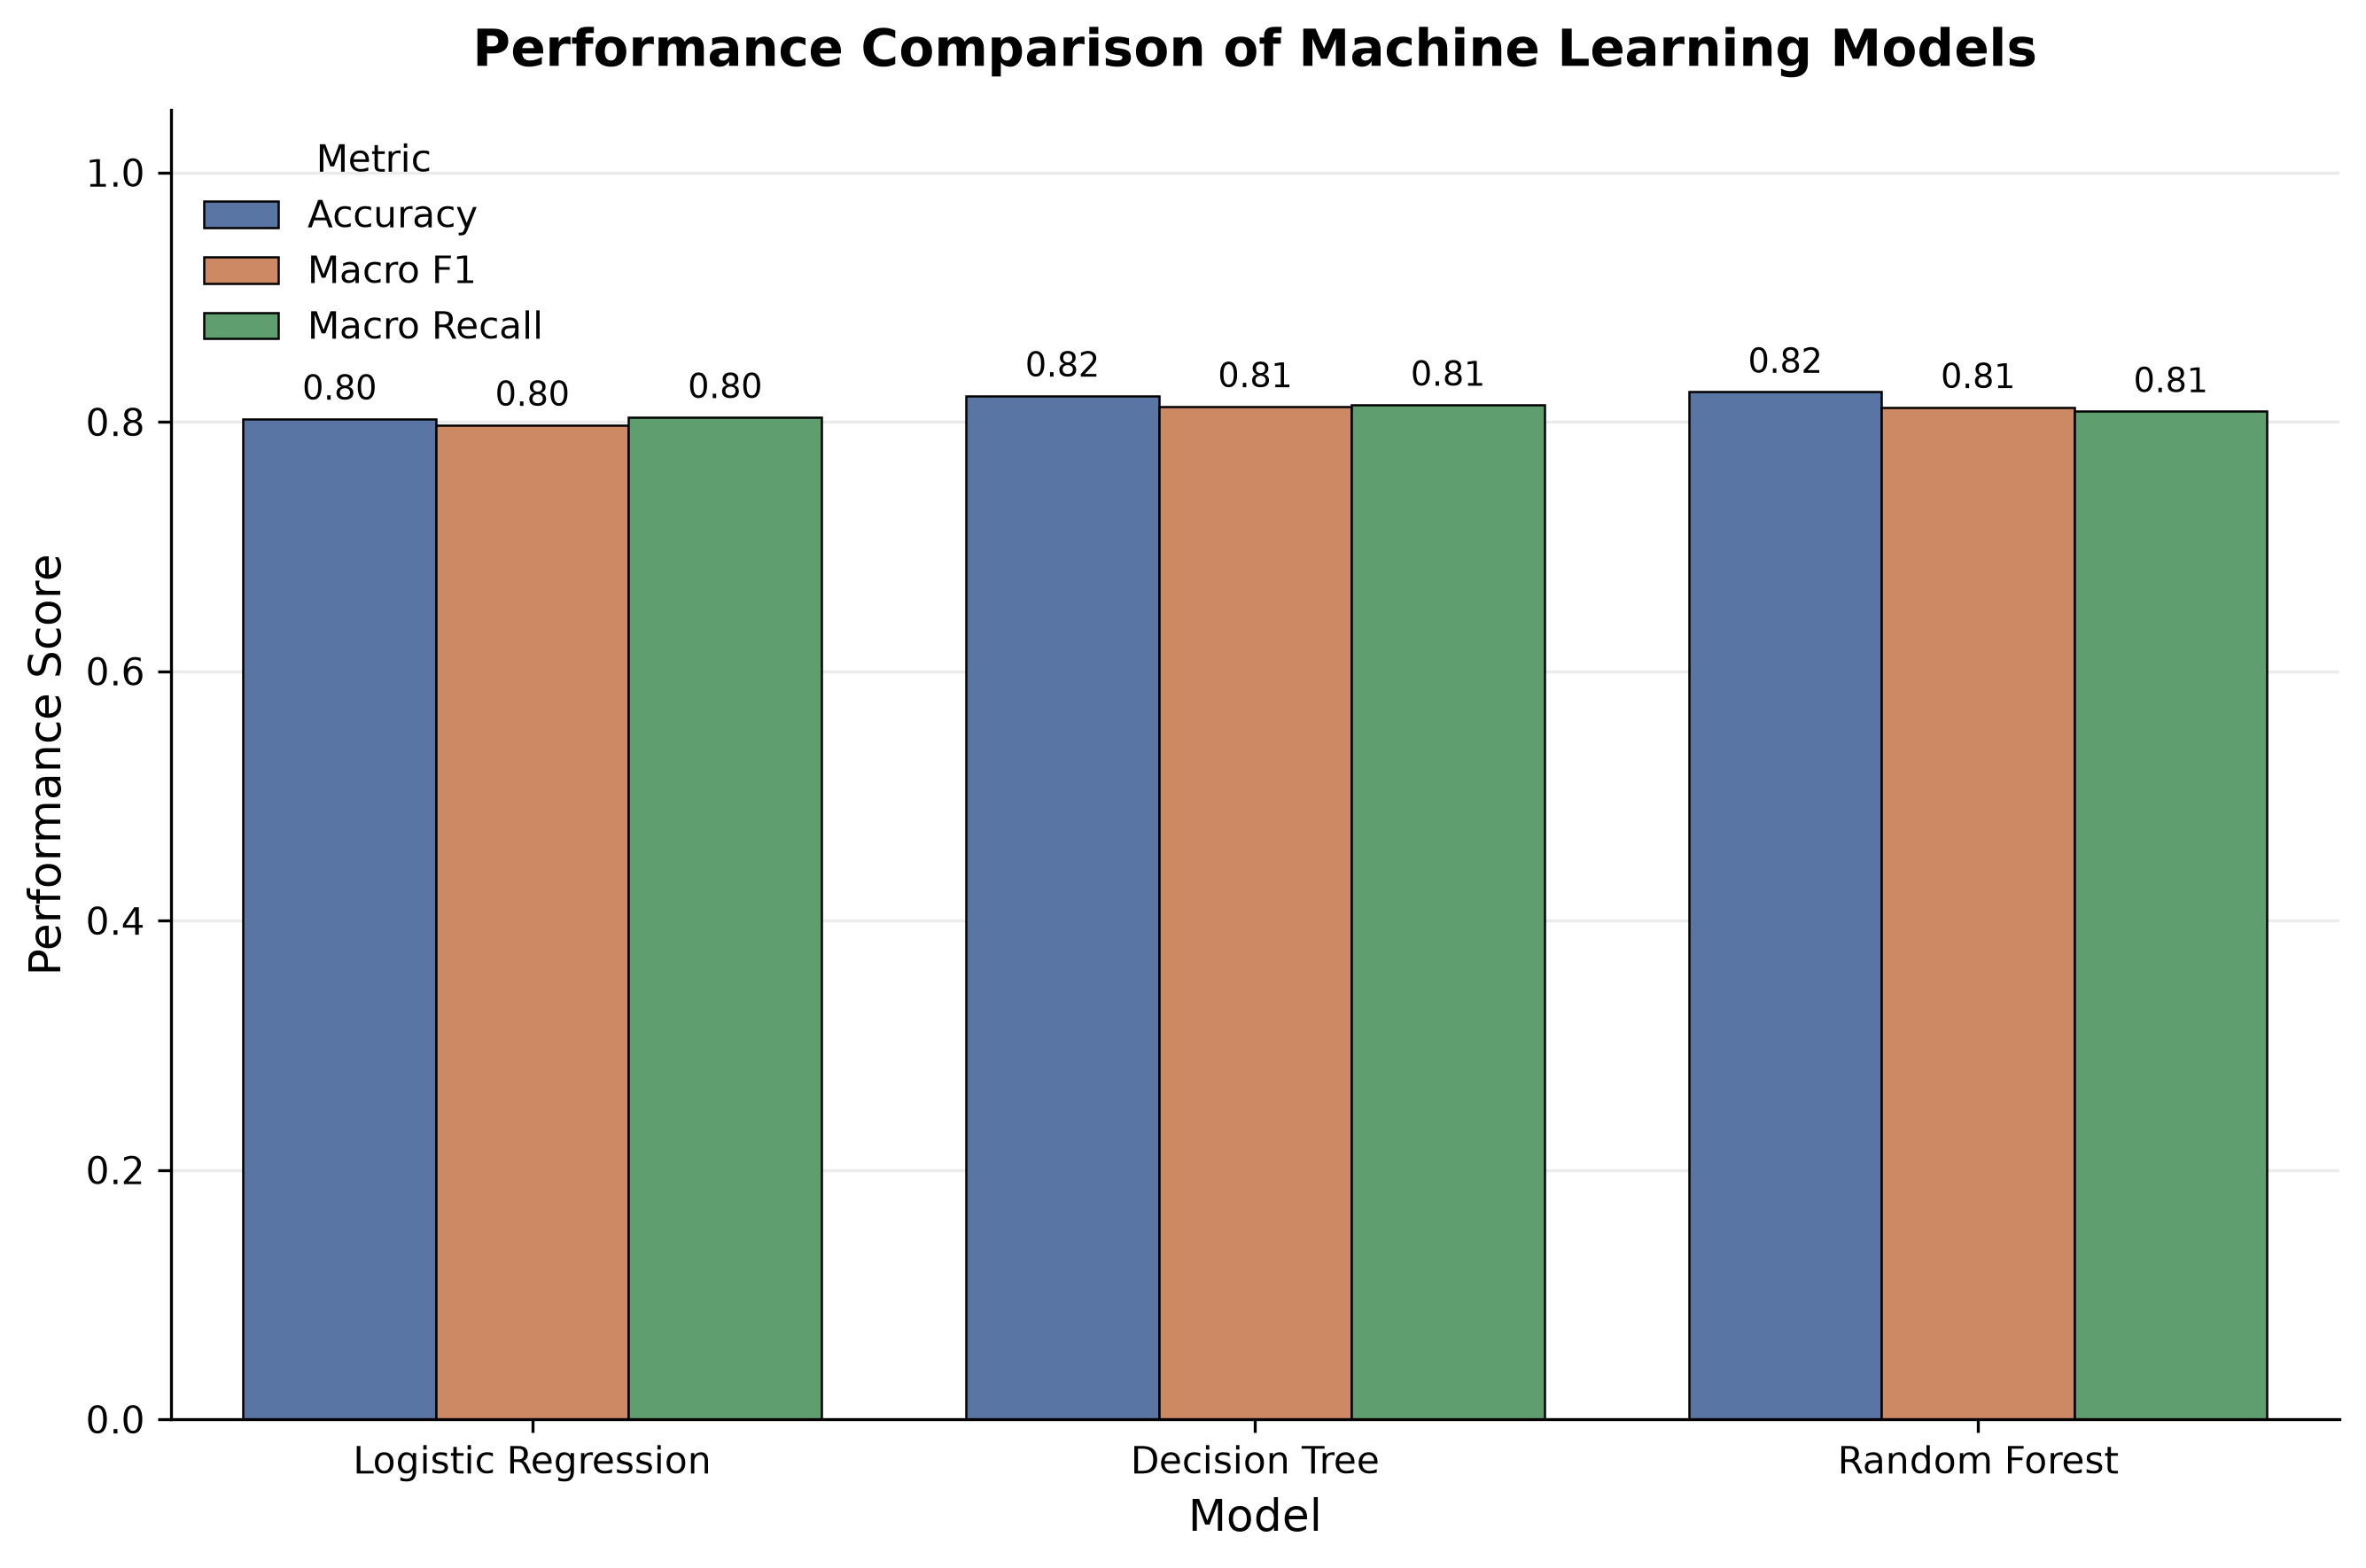

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model order
model_order = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

# Metrics used for comparison
metric_columns = {
    'test_accuracy': 'Accuracy',
    'test_f1_macro': 'Macro F1',
    'test_recall_macro': 'Macro Recall'
}

# Select required columns
plot_data = results_df[
    ['model', 'test_accuracy', 'test_f1_macro', 'test_recall_macro']
].copy()

# Rename columns for the figure
plot_data = plot_data.rename(columns={
    'model': 'Model',
    'test_accuracy': 'Accuracy',
    'test_f1_macro': 'Macro F1',
    'test_recall_macro': 'Macro Recall'
})

# Convert wide format to long format
plot_long = plot_data.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Macro F1', 'Macro Recall'],
    var_name='Metric',
    value_name='Score'
)

# Academic color palette
metric_colors = {
    'Accuracy': '#4C72B0',
    'Macro F1': '#DD8452',
    'Macro Recall': '#55A868'
}

# Create the figure
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

sns.barplot(
    data=plot_long,
    x='Model',
    y='Score',
    hue='Metric',
    order=model_order,
    palette=metric_colors,
    edgecolor='black',
    linewidth=0.6,
    ax=ax
)

# Axis labels and title
ax.set_title(
    'Performance Comparison of Machine Learning Models',
    fontsize=14,
    fontweight='bold',
    pad=12
)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Performance Score', fontsize=12)

# Set the score range
ax.set_ylim(0, 1.05)

# Add grid lines
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add numerical values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=9
    )

# Adjust legend
ax.legend(
    title='Metric',
    frameon=False,
    loc='upper left'
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    'figure4_model_performance_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

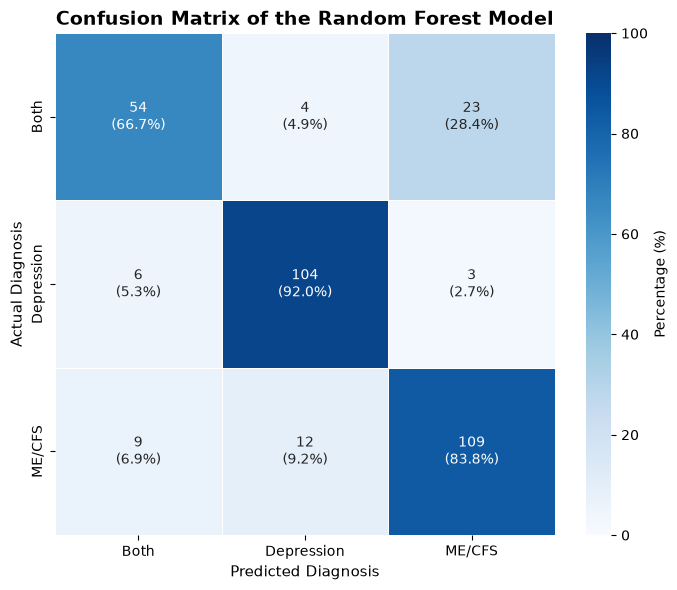

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Select the best model
best_model_name = 'Random Forest'
best_model = models[best_model_name]

# Fit the model and make predictions
best_model.fit(X_train_scaled, y_train_encoded)
y_pred_best = best_model.predict(X_test_scaled)

# Calculate confusion matrix
class_ids = np.arange(len(le.classes_))
cm = confusion_matrix(
    y_test_encoded,
    y_pred_best,
    labels=class_ids
)

# Convert each row into percentages
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# Add count and percentage to each cell
annotations = np.empty_like(cm, dtype=object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annotations[i, j] = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'

# Plot the confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_percent,
    annot=annotations,
    fmt='',
    cmap='Blues',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='white',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={'label': 'Percentage (%)'}
)

plt.title(
    'Confusion Matrix of the Random Forest Model',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Diagnosis', fontsize=11)
plt.ylabel('Actual Diagnosis', fontsize=11)

plt.tight_layout()
plt.savefig('Figure_5_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

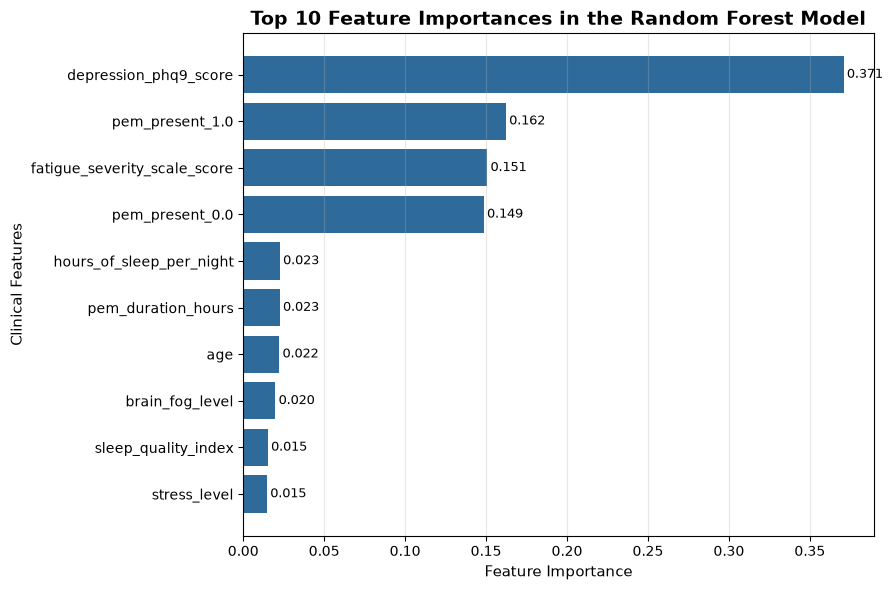

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the tuned Random Forest model
rf_model = models['Random Forest']

# Make sure the model has been fitted
rf_model.fit(X_train_scaled, y_train_encoded)

# Extract feature importance
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

# Select the top 10 most important features
feature_importance_df = (
    feature_importance_df
    .sort_values(by='Importance', ascending=False)
    .head(10)
    .sort_values(by='Importance', ascending=True)
)

# Plot feature importance
plt.figure(figsize=(9, 6))

bars = plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color='#2F6B9A'
)

plt.xlabel('Feature Importance', fontsize=11)
plt.ylabel('Clinical Features', fontsize=11)

plt.title(
    'Top 10 Feature Importances in the Random Forest Model',
    fontsize=14,
    fontweight='bold'
)

# Add importance values
for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('Figure_6_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()